#### For Visualizing Learning Rate Change

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# model to use
model = torch.nn.Linear(1,1)

In [ ]:
# # each scheduler must contain epoch value!
# scheduler:
# scheduler_type: 'cosine_warmup_restart' # one of cosine_warmup_restart or one_cycle
# cosine_warmup_restart:
#     epoch: 60
#     lr_min: 0.00001
#     decay: 0.2
#     cycle_mul: 1.0
#     cycle_limit: 100
#     warmup_lr: 10
#     warmup_lr_init: 0.000001
#     step_size: 30

# one_cycle:
#     epoch: 60
#     max_lr: 0.0006
#     pct: 0.3
#     anneal_strategy: 'cos'
#     div: 60
#     f_div: 10000
#     three_phase: False

# multi_step:
#     epoch: 60
#     milestones: [20, 40, 50]
#     gamma: 0.5

## My Custom LR Settings

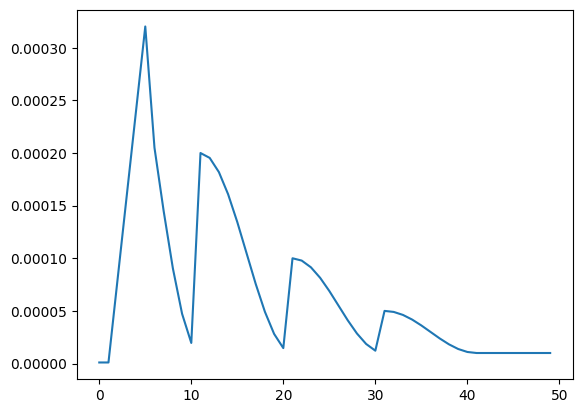

In [22]:
import timm.scheduler

# lr: 0.0006
# cosine_warmup_restart:
#     epoch: 60
#     lr_min: 0.00001
#     decay: 0.2
#     cycle_mul: 1.0
#     cycle_limit: 100
#     warmup_lr: 10
#     warmup_lr_init: 0.000001
#     step_size: 30

LR=0.0004
LR_MIN=0.00001
DECAY=0.5
MUL=1.0
LIMIT=4
WARMUP=5
WARMUP_INIT=0.000001
STEP_SIZE=10
EPOCHS=50

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = timm.scheduler.cosine_lr.CosineLRScheduler(optimizer, t_initial=STEP_SIZE, lr_min=LR_MIN, cycle_mul=MUL, cycle_decay=DECAY,
                                                       cycle_limit=LIMIT, warmup_t=WARMUP, warmup_lr_init=WARMUP_INIT)


lrs = []
for i in range(EPOCHS):
    optimizer.step()
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step(i)

plt.plot(range(EPOCHS), lrs)
plt.show()

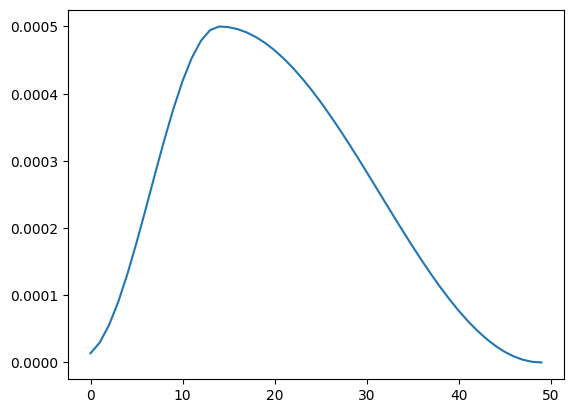

In [32]:
import timm.scheduler

# one_cycle:
#     epoch: 60
#     max_lr: 0.0006
#     pct: 0.3
#     anneal_strategy: 'cos'
#     div: 60
#     f_div: 10000
#     three_phase: False

EPOCHS=50
STEP_PER_EPOCH=432
MAX_LR=0.0005
PCT=0.3
ANNEAL_STRATEGY='cos' # 'cos' or 'linear'
DIV=60
F_DIV=10000
THREE_PHASE=False
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=MAX_LR, epochs=EPOCHS, steps_per_epoch=STEP_PER_EPOCH, pct_start=PCT,
                                                anneal_strategy=ANNEAL_STRATEGY, div_factor=DIV, final_div_factor=F_DIV, three_phase=THREE_PHASE)

lrs = []
for i in range(EPOCHS):
    for j in range(STEP_PER_EPOCH):
        optimizer.step()
        scheduler.step()
    lrs.append(optimizer.param_groups[0]['lr'])

plt.plot(range(EPOCHS), lrs)
plt.show()

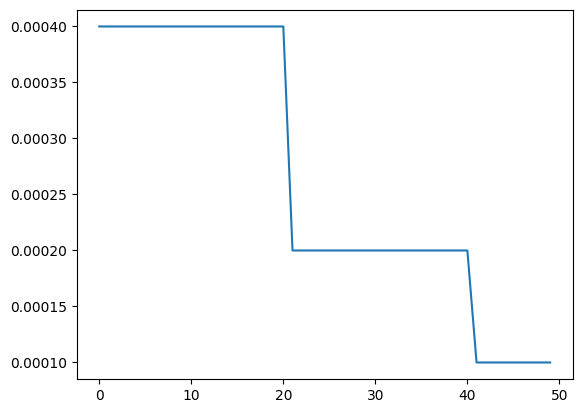

In [35]:
import timm.scheduler

# multi_step:
#     epoch: 60
#     milestones: [20, 40, 50]
#     gamma: 0.5

EPOCHS = 50
MILESTONES = [20, 40, 50]
GAMMA=0.5

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=MILESTONES, gamma=GAMMA)

lrs = []
for i in range(EPOCHS):
    optimizer.step()
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step(i)

plt.plot(range(EPOCHS), lrs)
plt.show()